# Biohub Cell Tracking — Dataset & Visualization Walkthrough

A beginner-friendly tour of the 3D+time microscopy data for the **Biohub Cell
Tracking During Development** Kaggle competition. This notebook does not
train anything, it's purely for building intuition before you write
detection/tracking code.

**Data layout actually used here** (matches the real competition structure):
```
train/
    44b6_0113de3b.zarr   <- raw 3D+time image volume
    44b6_0113de3b.geff   <- ground-truth graph (nodes+edges) for that same video
    44b6_0b24845f.zarr
    44b6_0b24845f.geff
    ...
test/
    ...zarr only (no ground truth, obviously)
sample_submission.csv
```
Each `.geff` is itself a small zarr-based graph store (not a CSV), see
[the GEFF spec](https://github.com/live-image-tracking-tools/geff). We read it directly with the zarr library below. No extra installs are needed except zarr (if you are running this in a Kaggle environment).

1. About the dataset
2. Looking at the raw 3D microscopy volumes
3. Visualizing *where the cells are* (detection) on training images
4. Full 3D scatter views of detected/annotated cells
5. Extra exploratory plots useful before modeling

Edit `COMPETITION_DIR` in the Config cell to match your Kaggle input
directory, then run top to bottom.

In [32]:
!pip install zarr

## 0. Setup

In [33]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline


In [34]:
# ----------------------------------------------------------------------------
# CONFIG — edit if your input path differs. Run the discovery cell below if unsure.
# ----------------------------------------------------------------------------
COMPETITION_DIR = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
TRAIN_DIR = COMPETITION_DIR / "train"
TEST_DIR = COMPETITION_DIR / "test"

SCALE = {"z": 1.625, "y": 0.40625, "x": 0.40625}   # physical voxel size (microns)


### Quick discovery (run once if you don't know the exact paths)

In [35]:
for p in sorted(Path("/kaggle/input").iterdir()):
    print(p)

print()
print("First 10 entries under train/:")
for p in sorted(TRAIN_DIR.iterdir())[:10]:
    print(" ", p.name)


/kaggle/input/competitions

First 10 entries under train/:
  44b6_0113de3b.geff
  44b6_0113de3b.zarr
  44b6_0b24845f.geff
  44b6_0b24845f.zarr
  44b6_0c582fdc.geff
  44b6_0c582fdc.zarr
  44b6_0db75fae.geff
  44b6_0db75fae.zarr
  44b6_12dfb391.geff
  44b6_12dfb391.zarr


### GEFF reader

A `.geff` store is a zarr group with `nodes/ids`, `nodes/props/<name>/values`
(one array per node attribute: `t`, `z`, `y`, `x`, ...), and `edges/ids`
(an `(E, 2)` array of `[source_node_id, target_node_id]`). We read it with
plain `zarr` — no `geff` package install required. Values are converted
back to voxel units if the file stores them in physical microns, so they
line up directly with the raw image array.

In [36]:
def list_train_datasets(train_dir: Path) -> list:
    """Dataset names present as BOTH a .zarr and a .geff pair."""
    zarr_names = {p.stem for p in train_dir.iterdir() if p.suffix == ".zarr"}
    geff_names = {p.stem for p in train_dir.iterdir() if p.suffix == ".geff"}
    return sorted(zarr_names & geff_names)


def find_geff_path(train_dir: Path, dataset_name: str) -> Path:
    direct = train_dir / f"{dataset_name}.geff"
    if direct.exists():
        return direct
    nested = train_dir / f"{dataset_name}.zarr" / f"{dataset_name}.geff"
    if nested.exists():
        return nested
    raise FileNotFoundError(f"No .geff found for '{dataset_name}' under {train_dir}")


def read_geff(geff_path: Path) -> tuple:
    g = zarr.open_group(str(geff_path), mode="r")
    meta = dict(g.attrs)["geff"]
    axes = meta.get("axes")

    node_ids = np.asarray(g["nodes/ids"])
    props_grp = g["nodes/props"]

    axis_lookup = {ax["name"]: ax for ax in axes} if axes else \
        {n: {"name": n, "unit": None} for n in ("t", "z", "y", "x")}

    cols = {}
    for name in ("t", "z", "y", "x"):
        if name not in axis_lookup or name not in props_grp:
            continue
        vals = np.asarray(props_grp[name]["values"]).astype(np.float64)
        unit = axis_lookup[name].get("unit")
        if name in SCALE and unit and "micro" in str(unit).lower():
            vals = vals / SCALE[name]
        cols[name] = vals

    nodes_df = pd.DataFrame({"node_id": node_ids, **cols})

    if "edges" in g and "ids" in g["edges"]:
        edge_ids = np.asarray(g["edges/ids"])
    else:
        edge_ids = np.empty((0, 2), dtype=np.int64)
    edges_df = pd.DataFrame({"source_id": edge_ids[:, 0], "target_id": edge_ids[:, 1]})

    return nodes_df, edges_df


dataset_names = list_train_datasets(TRAIN_DIR)
print(f"{len(dataset_names)} training datasets found (paired .zarr + .geff).")
print("First few:", dataset_names[:5])


199 training datasets found (paired .zarr + .geff).
First few: ['44b6_0113de3b', '44b6_0b24845f', '44b6_0c582fdc', '44b6_0db75fae', '44b6_12dfb391']


## 1. About the dataset

Physical voxel size is anisotropic: **z = 1.625 µm** per voxel but
**y = x = 0.40625 µm**, the microscope resolves much more detail within a
plane than between planes (~4x coarser along Z). This matters a lot for
detection/tracking: a "round" cell in physical space looks squashed along Z
in voxel space, and distances must be scaled by this before thresholding
anything (e.g. a max-linking-distance).

In [37]:
DATASET_NAME = "44b6_12dfb391"
print(f"Exploring dataset: {DATASET_NAME}")

zarr_path = TRAIN_DIR / f"{DATASET_NAME}.zarr"
root = zarr.open_group(str(zarr_path), mode="r")
arr = root["0"] if "0" in root else root  # handle both OME-zarr multiscale and flat layouts
print(f"Zarr array shape (T, Z, Y, X): {arr.shape}, dtype: {arr.dtype}")
print(f"Physical volume per frame (Z, Y, X) in microns: "
      f"{tuple(round(s * SCALE[ax], 1) for s, ax in zip(arr.shape[1:], ['z','y','x']))}")

geff_path = find_geff_path(TRAIN_DIR, DATASET_NAME)
nodes_this, edges_this = read_geff(geff_path)
print(f"\nThis dataset: {len(nodes_this)} annotated nodes, {len(edges_this)} edges, "
      f"spanning t=0..{int(nodes_this['t'].max())}")
display(nodes_this.head(8))


Exploring dataset: 44b6_12dfb391
Zarr array shape (T, Z, Y, X): (100, 64, 256, 256), dtype: uint16
Physical volume per frame (Z, Y, X) in microns: (104.0, 104.0, 104.0)

This dataset: 788 annotated nodes, 773 edges, spanning t=0..99


,node_id,t,z,y,x
0,106000000037,0.0,35.0,61.0,189.0
1,106000000040,0.0,15.0,194.0,55.0
2,106000000041,0.0,7.0,239.0,56.0
3,106000000043,0.0,27.0,211.0,109.0
4,106000000056,0.0,40.0,127.0,130.0
5,106000000064,0.0,39.0,199.0,94.0
6,106000000081,0.0,18.0,253.0,94.0
7,106000000082,0.0,24.0,123.0,86.0


In [38]:
# ============================================================================
# DIAGNOSTIC — is this dataset just sparse, or is something wrong?
# ============================================================================

# --------------------------------------------------------------------------
# 1. Check the FULL video (not just your 40-frame window) for the current dataset.
# --------------------------------------------------------------------------
nodes_this, edges_this = read_geff(geff_path)
full_counts = nodes_this.groupby("t").size()
print(f"Dataset: {DATASET_NAME}")
print(f"Full video length: {int(nodes_this['t'].max()) + 1} frames")
print(f"Total annotated nodes across the ENTIRE video: {len(nodes_this)}")
print(f"Max cells in any single frame: {full_counts.max()} (at t={int(full_counts.idxmax())})")
print(f"Frames with >1 cell: {(full_counts > 1).sum()} / {len(full_counts)}")

if full_counts.max() <= 2:
    print("\n-> This dataset genuinely has ~1-2 annotated cells for its entire "
          "length. That's real (sparse GT), not a loading bug for THIS dataset "
          "— but let's find a denser one to animate instead.")

# --------------------------------------------------------------------------
# 2. Scan a sample of datasets and report how many cells each one has at its
#    busiest frame, so you can pick a denser one on purpose.
# --------------------------------------------------------------------------
SCAN_N = min(30, len(dataset_names))
scan_names = dataset_names[:SCAN_N]

rows = []
for name in scan_names:
    n_df, e_df = read_geff(find_geff_path(TRAIN_DIR, name))
    if len(n_df) == 0:
        rows.append({"dataset": name, "n_frames": 0, "max_cells_in_frame": 0, "total_nodes": 0})
        continue
    per_t = n_df.groupby("t").size()
    rows.append({
        "dataset": name,
        "n_frames": int(n_df["t"].max()) + 1,
        "max_cells_in_frame": int(per_t.max()),
        "total_nodes": len(n_df),
    })

scan_df = pd.DataFrame(rows).sort_values("max_cells_in_frame", ascending=False)
print(f"\nDensity scan across {SCAN_N} datasets (busiest frame first):")
display(scan_df.head(15))

DENSEST_DATASET = scan_df.iloc[0]["dataset"]
print(f"\nDensest dataset found: '{DENSEST_DATASET}' "
      f"(up to {scan_df.iloc[0]['max_cells_in_frame']} cells in one frame). "
      f"Set DATASET_NAME = '{DENSEST_DATASET}' and re-run Section 1 onward "
      f"to visualize/animate this one instead.")

Dataset: 44b6_12dfb391
Full video length: 100 frames
Total annotated nodes across the ENTIRE video: 788
Max cells in any single frame: 11 (at t=8)
Frames with >1 cell: 100 / 100

Density scan across 30 datasets (busiest frame first):


,dataset,n_frames,max_cells_in_frame,total_nodes
4,44b6_12dfb391,100,11,788
15,44b6_3a861e03,100,11,935
24,44b6_668e0cc7,100,10,643
22,44b6_587a1e22,100,7,381
29,44b6_7a302da0,100,7,516
18,44b6_415c0a3a,100,6,331
14,44b6_341df25f,100,4,216
16,44b6_3bb3690f,100,4,400
20,44b6_551a5dba,100,4,228
9,44b6_24264f12,87,4,230



Densest dataset found: '44b6_12dfb391' (up to 11 cells in one frame). Set DATASET_NAME = '44b6_12dfb391' and re-run Section 1 onward to visualize/animate this one instead.


### How many cells are annotated per frame?

Check this *before* picking a frame to visualize, many of these videos are
developmental time-lapses that start from very few cells and grow over
time, so an early frame (like t=0) can genuinely have just 1-2 annotated
cells. That's real biology, not a bug.

In [39]:
counts_per_t_preview = nodes_this.groupby("t").size()
print("Image array shape (T, Z, Y, X):", arr.shape)
print("\nCells annotated per frame — first 10 frames:")
print(counts_per_t_preview.head(10))
print("\nCells annotated per frame — last 10 frames:")
print(counts_per_t_preview.tail(10))

BEST_T = int(counts_per_t_preview.idxmax())
print(f"\nFrame with the most annotated cells: t={BEST_T} "
      f"({counts_per_t_preview.max()} cells) — using this as the default T_VIEW below.\n"
      f"Change T_VIEW manually in the next section if you want a different frame.")


Image array shape (T, Z, Y, X): (100, 64, 256, 256)

Cells annotated per frame — first 10 frames:
t
0.0    10
1.0    10
2.0    10
3.0    10
4.0    10
5.0    10
6.0    10
7.0    10
8.0    11
9.0    11
dtype: int64

Cells annotated per frame — last 10 frames:
t
90.0    3
91.0    3
92.0    3
93.0    3
94.0    3
95.0    3
96.0    3
97.0    3
98.0    3
99.0    3
dtype: int64

Frame with the most annotated cells: t=8 (11 cells) — using this as the default T_VIEW below.
Change T_VIEW manually in the next section if you want a different frame.


### Peeking at the whole training set (sampled)

Loading all 370+ `.geff` files just to count nodes would be slow. This
samples a handful to give you a feel for typical dataset size and density
without reading everything.

In [40]:
import random

SAMPLE_SIZE = min(15, len(dataset_names))
sample_names = random.Random(0).sample(dataset_names, SAMPLE_SIZE)

rows = []
for name in sample_names:
    n_df, e_df = read_geff(find_geff_path(TRAIN_DIR, name))
    rows.append({"dataset": name, "n_nodes": len(n_df), "n_edges": len(e_df),
                 "n_frames": int(n_df["t"].max()) + 1 if len(n_df) else 0})

summary = pd.DataFrame(rows)
display(summary)
print(f"\nAcross this sample of {SAMPLE_SIZE} datasets: "
      f"median {summary['n_nodes'].median():.0f} nodes, "
      f"median {summary['n_frames'].median():.0f} frames per video.")


,dataset,n_nodes,n_edges,n_frames
0,6bba_372c8cb8,1036,1007,100
1,6bba_fbc898dc,655,639,100
2,6bba_4aa14c89,707,681,100
3,44b6_267148e4,280,277,100
4,44b6_e31261b4,116,113,97
5,6bba_74686d6a,586,576,100
6,6bba_6ca87370,1081,1052,100
7,6bba_3fda6b25,1207,1179,100
8,6bba_09961292,1950,1871,100
9,6bba_6479435d,617,580,100



Across this sample of 15 datasets: median 661 nodes, median 100 frames per video.


## 2. Looking at the raw 3D microscopy volume

A single timepoint is a 3D stack of grayscale images (one per Z-plane). The
easiest way to *see* a whole 3D volume at once on a 2D screen is a **maximum
intensity projection (MIP)**: for every pixel column, take the brightest
value across all Z-planes (or all Y, or all X). Bright blobs in the MIP are
candidate cells.

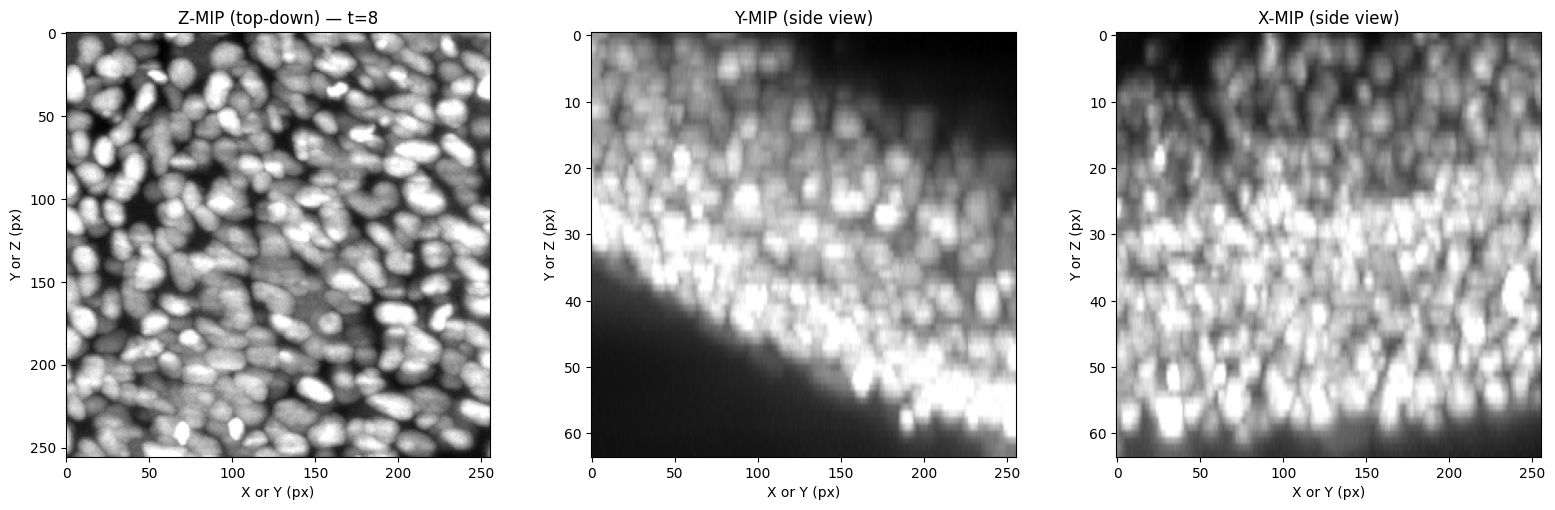

Notice the side views (Y-MIP, X-MIP) look 'squashed' — that's the physical
aspect ratio correction for the anisotropic voxel size (z is coarser).


In [41]:
T_VIEW = BEST_T  # which timepoint to look at (defaults to the frame with the most annotated cells)

volume = arr[T_VIEW].astype(np.float32)   # (Z, Y, X)
q_low, q_high = np.quantile(volume, [0.001, 0.999])
volume_norm = np.clip((volume - q_low) / (q_high - q_low + 1e-6), 0, 1)

mip_z = volume_norm.max(axis=0)  # top-down view, shape (Y, X)
mip_y = volume_norm.max(axis=1)  # side view,      shape (Z, X)
mip_x = volume_norm.max(axis=2)  # side view,      shape (Z, Y)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(mip_z, cmap="gray"); axes[0].set_title(f"Z-MIP (top-down) — t={T_VIEW}")
axes[1].imshow(mip_y, cmap="gray", aspect=SCALE["z"] / SCALE["x"]); axes[1].set_title("Y-MIP (side view)")
axes[2].imshow(mip_x, cmap="gray", aspect=SCALE["z"] / SCALE["y"]); axes[2].set_title("X-MIP (side view)")
for ax in axes:
    ax.set_xlabel("X or Y (px)"); ax.set_ylabel("Y or Z (px)")
plt.tight_layout()
plt.show()

print("Notice the side views (Y-MIP, X-MIP) look 'squashed' — that's the physical\n"
      "aspect ratio correction for the anisotropic voxel size (z is coarser).")


## 3. Visualizing cell detection on training images

"Detection" means: given a raw image, output the (z, y, x) centroid of every
cell. Here we overlay the **ground-truth** centroids on the raw image so you
can see exactly what a detector is trying to predict. (Swap `nodes_this` for
your own model's predicted coordinates later to visually debug detections.)

11 annotated cells at t=8


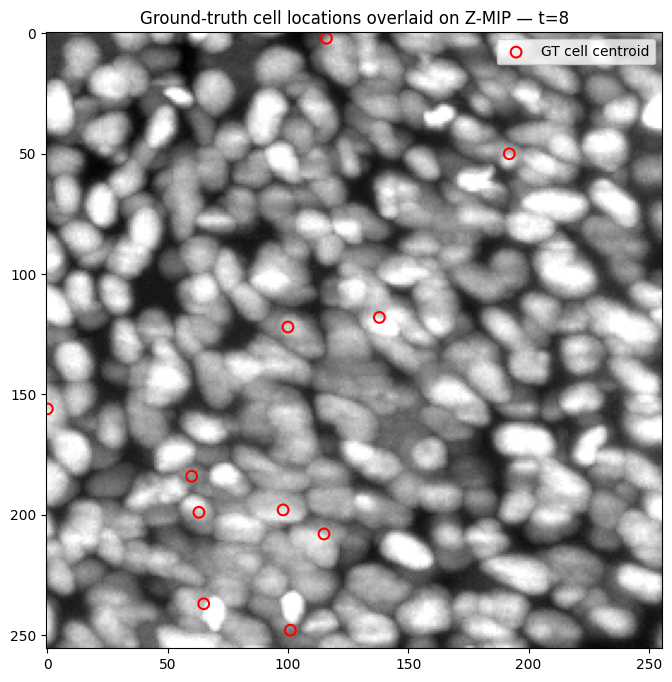

In [42]:
nodes_t = nodes_this[nodes_this["t"] == T_VIEW]
print(f"{len(nodes_t)} annotated cells at t={T_VIEW}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mip_z, cmap="gray")
ax.scatter(nodes_t["x"], nodes_t["y"], s=60, facecolors="none",
           edgecolors="red", linewidths=1.5, label="GT cell centroid")
ax.set_title(f"Ground-truth cell locations overlaid on Z-MIP — t={T_VIEW}")
ax.legend(loc="upper right")
plt.show()


### Why "local peak detection" works (general principle)

A very simple (and surprisingly effective) baseline detector looks for local
brightness maxima: a pixel is a "cell" if it's brighter than everything in a
small neighborhood around it. Here's what the intensity looks like along a
line through one real cell that bump is exactly what a peak detector is
looking for.

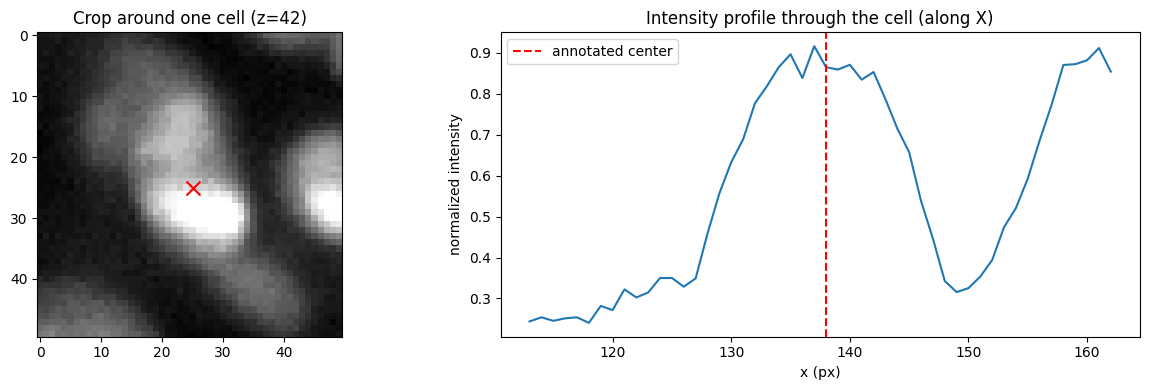

In [43]:
if len(nodes_t) > 0:
    example = nodes_t.iloc[len(nodes_t) // 2]
    ez, ey, ex = int(example["z"]), int(example["y"]), int(example["x"])

    half = 25
    x0, x1 = max(0, ex - half), min(volume_norm.shape[2], ex + half)
    profile = volume_norm[ez, ey, x0:x1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    crop = volume_norm[ez, max(0, ey - half):ey + half, x0:x1]
    axes[0].imshow(crop, cmap="gray")
    axes[0].scatter([ex - x0], [min(half, ey)], marker="x", color="red", s=100)
    axes[0].set_title(f"Crop around one cell (z={ez})")

    axes[1].plot(range(x0, x1), profile)
    axes[1].axvline(ex, color="red", linestyle="--", label="annotated center")
    axes[1].set_title("Intensity profile through the cell (along X)")
    axes[1].set_xlabel("x (px)"); axes[1].set_ylabel("normalized intensity")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("No annotated cells at this timepoint to illustrate — try a different T_VIEW.")


## 4. Full 3D view of detected cells

MIPs flatten away depth. A 3D scatter plot of the actual `(x, y, z)`
centroids preserves it, and lets you see dense vs. sparse regions, and cells
that overlap in the MIP but are actually far apart in Z.

Divisions (a cell with 2 children — i.e. mitosis) are highlighted separately
since they're the hardest tracking events to get right.

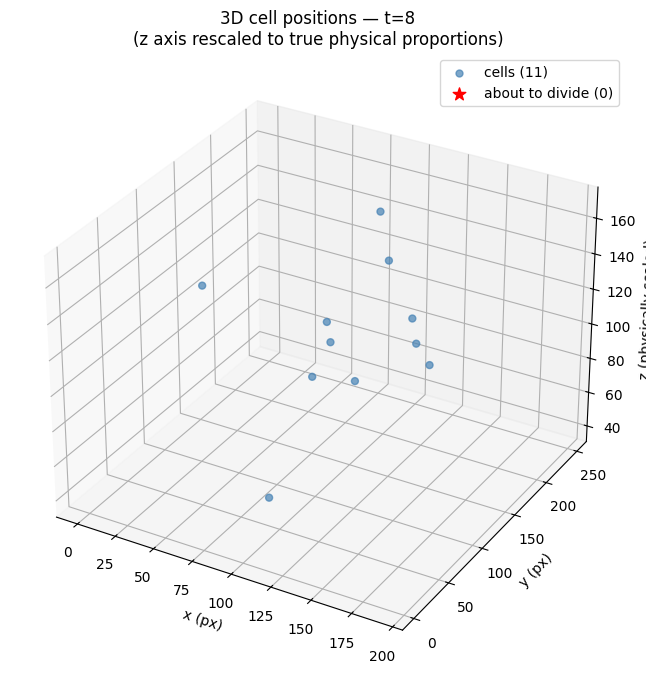

In [44]:
src_counts = edges_this["source_id"].value_counts()
dividing_ids = set(src_counts[src_counts >= 2].index)
nodes_t = nodes_t.copy()
nodes_t["is_dividing"] = nodes_t["node_id"].isin(dividing_ids)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

normal = nodes_t[~nodes_t["is_dividing"]]
dividing = nodes_t[nodes_t["is_dividing"]]

ax.scatter(normal["x"], normal["y"], normal["z"] * (SCALE["z"] / SCALE["x"]),
           s=25, c="steelblue", alpha=0.7, label=f"cells ({len(normal)})")
ax.scatter(dividing["x"], dividing["y"], dividing["z"] * (SCALE["z"] / SCALE["x"]),
           s=90, c="red", marker="*", label=f"about to divide ({len(dividing)})")

ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)"); ax.set_zlabel("z (physically-scaled)")
ax.set_title(f"3D cell positions — t={T_VIEW}\n(z axis rescaled to true physical proportions)")
ax.legend()
plt.show()


### Interactive version (optional — Plotly)

The static matplotlib plot above is fine for a quick look, but you can't
rotate it. Plotly gives you a fully interactive 3D scatter (drag to rotate,
scroll to zoom) which is very useful for actually inspecting dense/crowded regions.

In [45]:
try:
    import plotly.graph_objects as go

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=normal["x"], y=normal["y"], z=normal["z"] * (SCALE["z"] / SCALE["x"]),
        mode="markers", marker=dict(size=3, color="steelblue", opacity=0.7),
        name=f"cells ({len(normal)})",
    ))
    fig.add_trace(go.Scatter3d(
        x=dividing["x"], y=dividing["y"], z=dividing["z"] * (SCALE["z"] / SCALE["x"]),
        mode="markers", marker=dict(size=6, color="red", symbol="diamond"),
        name=f"about to divide ({len(dividing)})",
    ))
    fig.update_layout(
        title=f"Interactive 3D cell positions — t={T_VIEW}",
        scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z (scaled)"),
        height=700,
    )
    fig.show()
except ImportError:
    print("plotly not available in this environment — the static matplotlib plot above still works fine.")


## 5. Cell lineage over time

Cells aren't static, each one moves and eventually divides or the track
ends. Plotting every edge as a line segment through (t, x, y) space shows
the full lineage structure: branch points are divisions.

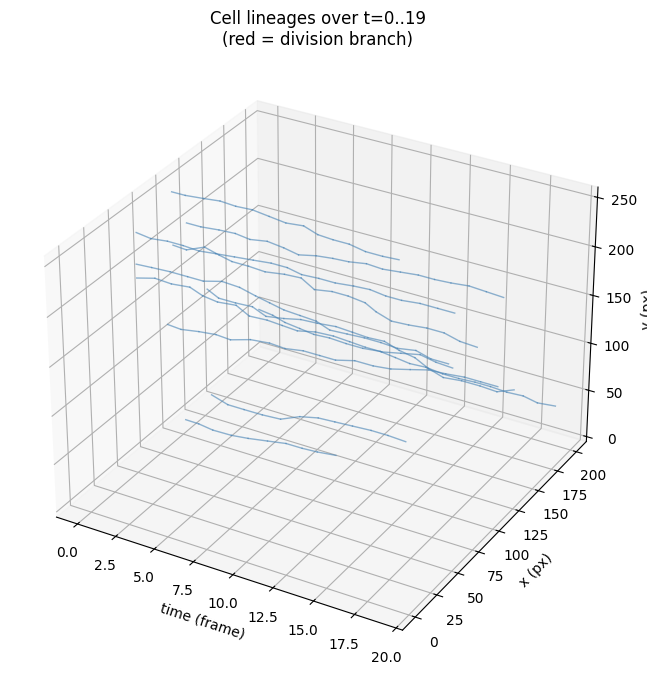

In [46]:
T_RANGE = range(0, min(20, int(nodes_this["t"].max()) + 1))  # first ~20 frames for readability

nodes_sub = nodes_this[nodes_this["t"].isin(T_RANGE)].set_index("node_id")
edges_sub = edges_this[edges_this["source_id"].isin(nodes_sub.index) &
                        edges_this["target_id"].isin(nodes_sub.index)]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for _, row in edges_sub.iterrows():
    a, b = nodes_sub.loc[row["source_id"]], nodes_sub.loc[row["target_id"]]
    color = "red" if (edges_sub["source_id"] == row["source_id"]).sum() >= 2 else "steelblue"
    ax.plot([a["t"], b["t"]], [a["x"], b["x"]], [a["y"], b["y"]], color=color, alpha=0.6, linewidth=1)

ax.set_xlabel("time (frame)"); ax.set_ylabel("x (px)"); ax.set_zlabel("y (px)")
ax.set_title(f"Cell lineages over t=0..{T_RANGE.stop - 1}\n(red = division branch)")
plt.show()


## 6. A few more useful EDA plots before you start modeling

These help you sanity-check assumptions your pipeline will rely on: how many
cells per frame (does density grow?), how long tracks typically run, how
often divisions happen, and how close together cells typically are (which
sets a sensible max-linking-distance for a tracker).

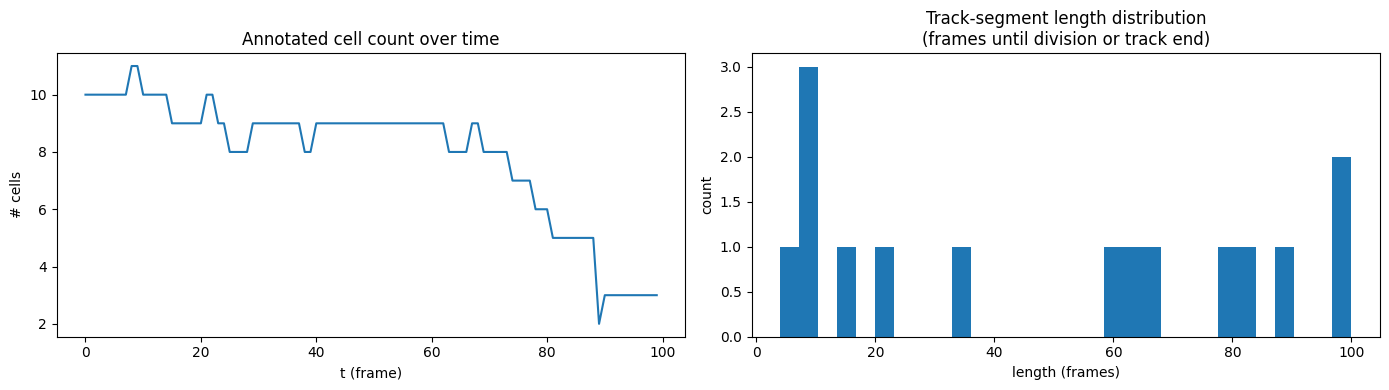

Divisions in this dataset: 1 (0.13% of all nodes are dividing parents)


In [47]:
counts_per_t = nodes_this.groupby("t").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(counts_per_t.index, counts_per_t.values)
axes[0].set_title("Annotated cell count over time")
axes[0].set_xlabel("t (frame)"); axes[0].set_ylabel("# cells")

out_deg = edges_this["source_id"].value_counts()
track_starts = set(nodes_this["node_id"]) - set(edges_this["target_id"])
edge_map = edges_this.groupby("source_id")["target_id"].apply(list).to_dict()

def track_length(start_id, edge_map, max_len=1000):
    length = 1
    cur = start_id
    for _ in range(max_len):
        children = edge_map.get(cur, [])
        if len(children) != 1:
            break
        cur = children[0]
        length += 1
    return length

lengths = [track_length(s, edge_map) for s in track_starts]

axes[1].hist(lengths, bins=30)
axes[1].set_title("Track-segment length distribution\n(frames until division or track end)")
axes[1].set_xlabel("length (frames)"); axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

n_divisions = (out_deg >= 2).sum()
print(f"Divisions in this dataset: {n_divisions} "
      f"({100 * n_divisions / max(len(nodes_this), 1):.2f}% of all nodes are dividing parents)")


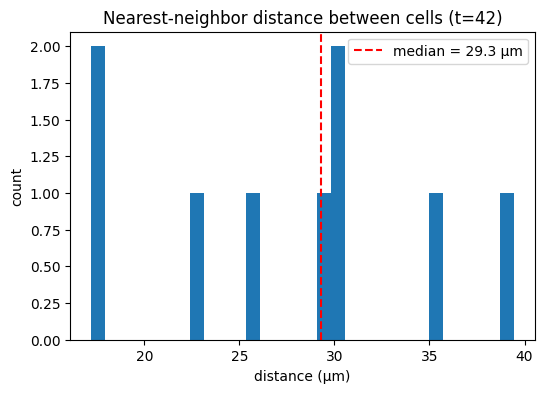

Median nearest-neighbor distance: 29.30 µm — cells linking across frames by much more than this in one timestep are probably a tracking error, not real motion.


In [48]:
from scipy.spatial import cKDTree

sample_t = int(nodes_this["t"].median())
pts = nodes_this[nodes_this["t"] == sample_t][["z", "y", "x"]].to_numpy().astype(np.float32)
pts_um = pts * np.array([SCALE["z"], SCALE["y"], SCALE["x"]])

if len(pts_um) > 1:
    tree = cKDTree(pts_um)
    dists, _ = tree.query(pts_um, k=2)
    nn_dist = dists[:, 1]

    plt.figure(figsize=(6, 4))
    plt.hist(nn_dist, bins=30)
    plt.axvline(np.median(nn_dist), color="red", linestyle="--",
                label=f"median = {np.median(nn_dist):.1f} µm")
    plt.title(f"Nearest-neighbor distance between cells (t={sample_t})")
    plt.xlabel("distance (µm)"); plt.ylabel("count")
    plt.legend()
    plt.show()

    print(f"Median nearest-neighbor distance: {np.median(nn_dist):.2f} µm — cells linking across "
          f"frames by much more than this in one timestep are probably a tracking error, not real motion.")


## Summary — what to take away as a beginner

- **Voxels are anisotropic** (z is ~4x coarser than x/y) — always work in
  physical microns when computing distances, not raw voxel indices, or
  your detector/tracker will be badly miscalibrated along Z.
- **Ground truth lives in `.geff` files, one per video**, not one master
  CSV — read each with `read_geff()` above, matched to its `.zarr` by
  filename stem.
- **Dataset names are compound** (e.g. `44b6_0113de3b`), not just the
  4-character prefix — that full string is what goes in the `dataset`
  column of your submission.
- **MIPs are for looking, not detecting** — they're a 2D convenience for
  humans; your actual detector should operate on the full 3D volume.
- **Divisions are rare but disproportionately important** — the competition
  metric gives them their own scoring term, and they're exactly the events
  a naive nearest-neighbor tracker gets wrong.
- **Ground truth is sparse** — not every visible cell is necessarily
  annotated, which is why the official metric has special handling for
  unmatched predictions rather than penalizing them outright.

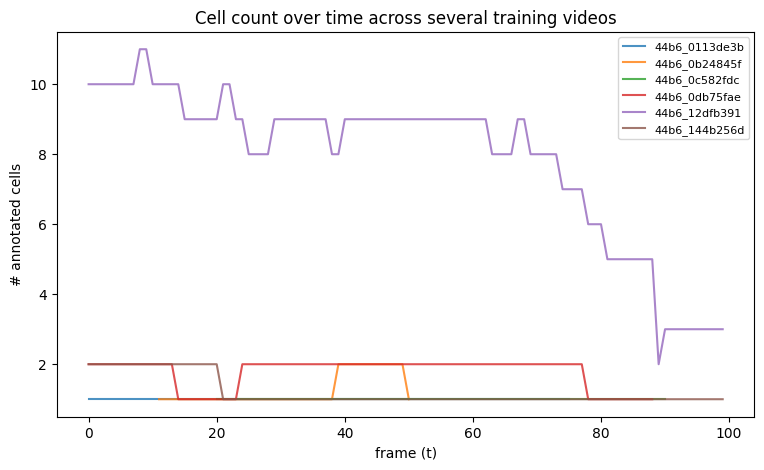

If most lines climb from a handful of cells to many, that confirms this
is developmental time-lapse data — training sees a wide range of cell
density, not just whatever a single early frame happens to show.


In [49]:
# Add this as a new cell anywhere after the geff_reader / list_train_datasets
# cells in the visualization notebook. It confirms the "starts sparse, ends
# dense" pattern across several videos at once, instead of just one.

import matplotlib.pyplot as plt

N_COMPARE = 6
compare_names = dataset_names[:N_COMPARE]  # or random.sample(dataset_names, N_COMPARE)

fig, ax = plt.subplots(figsize=(9, 5))
for name in compare_names:
    nodes_df, _ = read_geff(find_geff_path(TRAIN_DIR, name))
    counts = nodes_df.groupby("t").size()
    ax.plot(counts.index, counts.values, label=name, alpha=0.8)

ax.set_xlabel("frame (t)")
ax.set_ylabel("# annotated cells")
ax.set_title("Cell count over time across several training videos")
ax.legend(fontsize=8)
plt.show()

print("If most lines climb from a handful of cells to many, that confirms this\n"
      "is developmental time-lapse data — training sees a wide range of cell\n"
      "density, not just whatever a single early frame happens to show.")


In [50]:
# ============================================================================
# ANIMATION 1 — 2D: MIP + detected cells over time, saved as a GIF
# ============================================================================
# Uses matplotlib's PillowWriter (ships with Pillow, which is preinstalled
# on Kaggle — no ffmpeg needed). Also saves the frames as individual PNGs
# in case you'd rather flip through pictures than watch a video.

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path

# --------------------------------------------------------------------------
# Config
# --------------------------------------------------------------------------
T_START = 0
T_END = min(40, int(nodes_this["t"].max()) + 1)   # keep this modest — each frame reads a full 3D volume
T_STEP = 1
FPS = 4
OUT_DIR = Path("/kaggle/working/frames_2d")
OUT_DIR.mkdir(parents=True, exist_ok=True)
GIF_PATH = Path("/kaggle/working/cells_2d_over_time.gif")

frame_ts = list(range(T_START, T_END, T_STEP))
print(f"Rendering {len(frame_ts)} frames (t={T_START}..{T_END - 1})...")

# --------------------------------------------------------------------------
# Precompute a GLOBAL intensity range so brightness is consistent frame-to-
# frame (otherwise each frame re-normalizes and flickers).
# --------------------------------------------------------------------------
sample_idx = frame_ts[:: max(1, len(frame_ts) // 5)] or [T_START]
sample_stack = np.stack([arr[t].astype(np.float32) for t in sample_idx])
Q_LOW, Q_HIGH = np.quantile(sample_stack, [0.001, 0.999])
del sample_stack

# --------------------------------------------------------------------------
# Render each frame
# --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
im_artist = None
scat_artist = None
artists_per_frame = []  # for ArtistAnimation

for t in frame_ts:
    volume_t = arr[t].astype(np.float32)
    mip = np.clip((volume_t.max(axis=0) - Q_LOW) / (Q_HIGH - Q_LOW + 1e-6), 0, 1)

    cells_t = nodes_this[nodes_this["t"] == t]

    im_artist = ax.imshow(mip, cmap="gray", animated=True)
    scat_artist = ax.scatter(cells_t["x"], cells_t["y"], s=70, facecolors="none",
                              edgecolors="red", linewidths=1.5, animated=True)
    txt_artist = ax.text(0.02, 0.98, f"t={t}  ({len(cells_t)} cells)",
                          transform=ax.transAxes, color="yellow", fontsize=13,
                          va="top", animated=True,
                          bbox=dict(facecolor="black", alpha=0.5, pad=3))

    artists_per_frame.append([im_artist, scat_artist, txt_artist])

    # Also save this frame as a standalone PNG.
    fig_single, ax_single = plt.subplots(figsize=(8, 8))
    ax_single.imshow(mip, cmap="gray")
    ax_single.scatter(cells_t["x"], cells_t["y"], s=70, facecolors="none",
                       edgecolors="red", linewidths=1.5)
    ax_single.set_title(f"t={t}  ({len(cells_t)} annotated cells)")
    ax_single.axis("off")
    fig_single.savefig(OUT_DIR / f"frame_{t:04d}.png", bbox_inches="tight", dpi=100)
    plt.close(fig_single)

ax.axis("off")
ax.set_title("Cell detections over time (Z-MIP)")

ani = animation.ArtistAnimation(fig, artists_per_frame, interval=1000 / FPS, blit=True)
ani.save(GIF_PATH, writer=animation.PillowWriter(fps=FPS))
plt.close(fig)

print(f"\nSaved animated GIF to: {GIF_PATH}")
print(f"Saved {len(frame_ts)} individual PNG frames to: {OUT_DIR}")

Rendering 40 frames (t=0..39)...

Saved animated GIF to: /kaggle/working/cells_2d_over_time.gif
Saved 40 individual PNG frames to: /kaggle/working/frames_2d


In [51]:
# ============================================================================
# ANIMATION 2 — 3D: cell positions over time, saved as a GIF (rotating view)
# ============================================================================
# Two modes:
#   SHOW_TRAIL = False -> only the current frame's cells are shown (clean,
#       easy to read cell count/position at a glance)
#   SHOW_TRAIL = True  -> a fading trail of the last few frames is kept
#       visible too, which makes movement/division direction easier to see

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

T_START = 0
T_END = min(100, int(nodes_this["t"].max()) + 1)
T_STEP = 1
FPS = 4
SHOW_TRAIL = True
TRAIL_LENGTH = 3       # how many previous frames stay faintly visible
ROTATE = True          # slowly spin the camera while playing
GIF_PATH_3D = Path("/kaggle/working/cells_3d_over_time.gif")

frame_ts = list(range(T_START, T_END, T_STEP))
z_scale = SCALE["z"] / SCALE["x"]  # rescale z to true physical proportions

# Fixed axis limits across the whole animation (computed from ALL frames in
# range) so the plot doesn't rescale/jitter between frames.
in_range = nodes_this[nodes_this["t"].isin(frame_ts)]
x_lim = (in_range["x"].min(), in_range["x"].max())
y_lim = (in_range["y"].min(), in_range["y"].max())
z_lim = (in_range["z"].min() * z_scale, in_range["z"].max() * z_scale)

# Precompute which nodes are "about to divide" (source of >=2 edges), same
# definition as the static 3D plot earlier in the notebook.
src_counts_all = edges_this["source_id"].value_counts()
dividing_ids_all = set(src_counts_all[src_counts_all >= 2].index)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")


def render_frame(i):
    ax.clear()
    ax.set_xlim(*x_lim); ax.set_ylim(*y_lim); ax.set_zlim(*z_lim)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z (scaled)")

    t = frame_ts[i]

    if SHOW_TRAIL:
        for back in range(TRAIL_LENGTH, 0, -1):
            t_prev = t - back
            if t_prev < T_START:
                continue
            prev_cells = nodes_this[nodes_this["t"] == t_prev]
            alpha = 0.08 * (TRAIL_LENGTH - back + 1) / TRAIL_LENGTH
            ax.scatter(prev_cells["x"], prev_cells["y"], prev_cells["z"] * z_scale,
                       s=15, c="gray", alpha=alpha)

    cells_t = nodes_this[nodes_this["t"] == t]
    is_dividing = cells_t["node_id"].isin(dividing_ids_all)
    normal = cells_t[~is_dividing]
    dividing = cells_t[is_dividing]

    ax.scatter(normal["x"], normal["y"], normal["z"] * z_scale,
               s=35, c="steelblue", alpha=0.85, label=f"cells ({len(normal)})")
    ax.scatter(dividing["x"], dividing["y"], dividing["z"] * z_scale,
               s=100, c="red", marker="*", label=f"dividing ({len(dividing)})")

    ax.set_title(f"3D cell positions — t={t}  ({len(cells_t)} cells)")
    ax.legend(loc="upper left", fontsize=8)

    if ROTATE:
        ax.view_init(elev=20, azim=(i * 4) % 360)

    return []


ani = animation.FuncAnimation(fig, render_frame, frames=len(frame_ts),
                               interval=1000 / FPS, blit=False)
ani.save(GIF_PATH_3D, writer=animation.PillowWriter(fps=FPS))
plt.close(fig)

print(f"Saved 3D animated GIF to: {GIF_PATH_3D}")

Saved 3D animated GIF to: /kaggle/working/cells_3d_over_time.gif


Inspecting cell at (t=8, z=37, y=50, x=192)


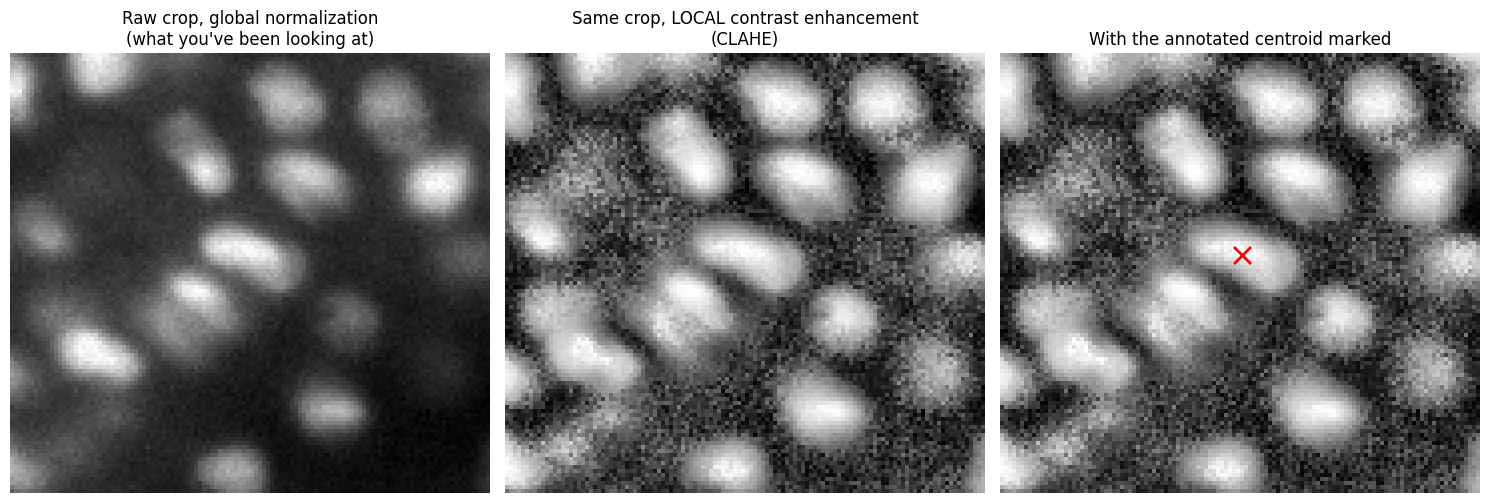


If the cell is much clearer in the middle/right panels than the left one,
that confirms it's a contrast problem, not a 'this isn't actually a cell'
problem — the raw signal is there, it just needs better normalization
for a human (or a detector) to pick it out easily.


In [52]:
# ============================================================================
# Why annotated cells look "invisible": raw vs. locally-enhanced contrast
# ============================================================================
# Run after Section 1 (needs nodes_this, arr, SCALE, T_VIEW).

from skimage import exposure

# Pick a specific annotated cell to inspect closely.
cells_t = nodes_this[nodes_this["t"] == T_VIEW]
if len(cells_t) == 0:
    raise ValueError(f"No annotated cells at t={T_VIEW} — pick a different T_VIEW first.")

example = cells_t.iloc[0]
ez, ey, ex = int(example["z"]), int(example["y"]), int(example["x"])
print(f"Inspecting cell at (t={T_VIEW}, z={ez}, y={ey}, x={ex})")

# The z-slice this cell ACTUALLY lives in (not the flattened MIP).
z_slice = arr[T_VIEW, ez].astype(np.float32)

half = 60
y0, y1 = max(0, ey - half), min(z_slice.shape[0], ey + half)
x0, x1 = max(0, ex - half), min(z_slice.shape[1], ex + half)
crop = z_slice[y0:y1, x0:x1]

# Global normalization (what the earlier MIP used).
crop_global = np.clip((crop - Q_LOW) / (Q_HIGH - Q_LOW + 1e-6), 0, 1) if "Q_LOW" in dir() else \
    np.clip((crop - crop.min()) / (crop.max() - crop.min() + 1e-6), 0, 1)

# Local contrast enhancement — CLAHE (adaptive histogram equalization).
crop_norm01 = (crop - crop.min()) / (crop.max() - crop.min() + 1e-6)
crop_clahe = exposure.equalize_adapthist(crop_norm01, clip_limit=0.03)

mark_y, mark_x = ey - y0, ex - x0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(crop_global, cmap="gray")
axes[0].set_title("Raw crop, global normalization\n(what you've been looking at)")

axes[1].imshow(crop_clahe, cmap="gray")
axes[1].set_title("Same crop, LOCAL contrast enhancement\n(CLAHE)")

axes[2].imshow(crop_clahe, cmap="gray")
axes[2].scatter([mark_x], [mark_y], marker="x", color="red", s=150, linewidths=2)
axes[2].set_title("With the annotated centroid marked")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\nIf the cell is much clearer in the middle/right panels than the left one,\n"
      "that confirms it's a contrast problem, not a 'this isn't actually a cell'\n"
      "problem — the raw signal is there, it just needs better normalization\n"
      "for a human (or a detector) to pick it out easily.")